In [47]:
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
df=pd.read_csv(r"C:\Users\K.Asus\Desktop\programing\Data_Analysis\TEST\داتا BMW\archive\bmw_global_sales_2018_2025.csv")

In [49]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [51]:
df.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

In [52]:
df[['Units_Sold', 'Avg_Price_EUR', 'Revenue_EUR']].describe()

,Units_Sold,Avg_Price_EUR,Revenue_EUR
count,3072.000000,3072.000000,3.072000e+03
mean,7980.288086,63854.561523,5.113995e+08
std,3174.917444,14655.891299,2.431185e+08
min,2379.000000,40011.000000,1.045314e+08
25%,5225.500000,54500.250000,3.125504e+08
50%,7985.500000,63493.000000,4.808690e+08
75%,10528.250000,71489.500000,6.709141e+08
max,15914.000000,93994.000000,1.433482e+09


In [53]:
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

# 3. تحويل الأعمدة المالية والنسب إلى أرقام عشرية (Float)
financial_cols = ['Avg_Price_EUR', 'Revenue_EUR', 'BEV_Share', 
                  'Premium_Share', 'GDP_Growth', 'Fuel_Price_Index']

for col in financial_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. تحويل النصوص المتكررة إلى "Category" (لتحسين الأداء)
df['Region'] = df['Region'].astype('category')
df['Model'] = df['Model'].astype('category')

df.dtypes

Year                   int64
Month                  int64
Region              category
Model               category
Units_Sold             int64
Avg_Price_EUR          int64
Revenue_EUR            int64
BEV_Share            float64
Premium_Share        float64
GDP_Growth           float64
Fuel_Price_Index     float64
dtype: object

In [54]:
# 2. تنظيف عمود المنطقة (Region)
# إزالة المسافات وتحويل أول حرف لكبير
df['Region'] = df['Region'].str.strip().str.title()

# 3. تنظيف عمود الموديل (Model)
df['Model'] = df['Model'].str.strip()

# 4. مراجعة القيم الفريدة للتأكد من عدم وجود تكرار ناتج عن سوء التنسيق
print("المناطق الموجودة في الملف:")
print(df['Region'].unique())

print("\nالموديلات الموجودة في الملف:")
print(df['Model'].unique())


المناطق الموجودة في الملف:
['Europe' 'China' 'Usa' 'Restofworld']

الموديلات الموجودة في الملف:
['3 Series' '5 Series' 'X3' 'X5' 'X7' 'i4' 'iX' 'MINI']


Model
iX          3136912
i4          3125687
X7          3112074
X5          3085134
5 Series    3052524
Name: Units_Sold, dtype: int64


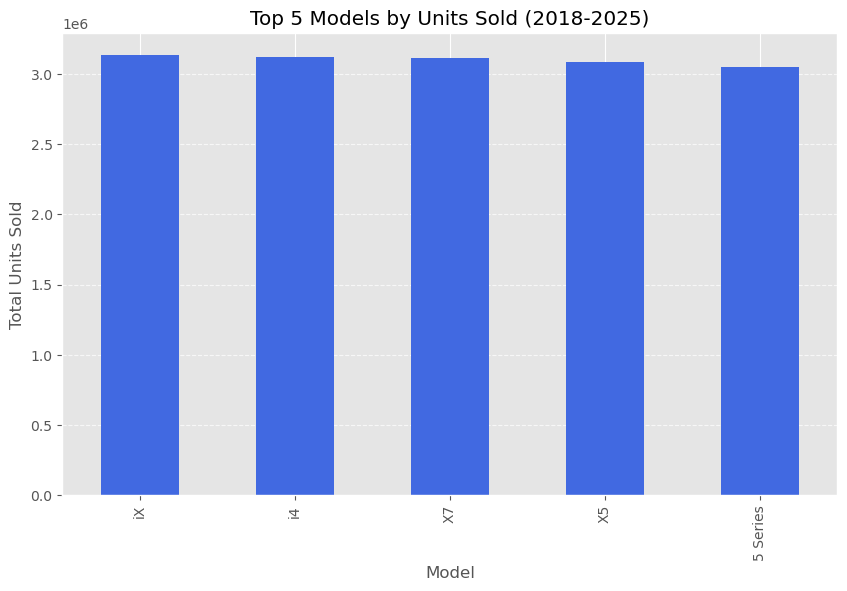

In [58]:
##(ما هي الموديلات الخمسة الأكثر مبيعاً من حيث عدد الوحدات؟)
##الاستفادة: تحديد الموديلات التي تسيطر على الحصة الأكبر من طلب العملاء، مما يساعد في تخطيط الإنتاج والمخزون.
top_models = df.groupby('Model')['Units_Sold'].sum().sort_values(ascending=False).head(5)
print(top_models)
plt.figure(figsize=(10, 6))
top_models.plot(kind='bar', color='royalblue')
plt.title('Top 5 Models by Units Sold (2018-2025)')
plt.ylabel('Total Units Sold')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

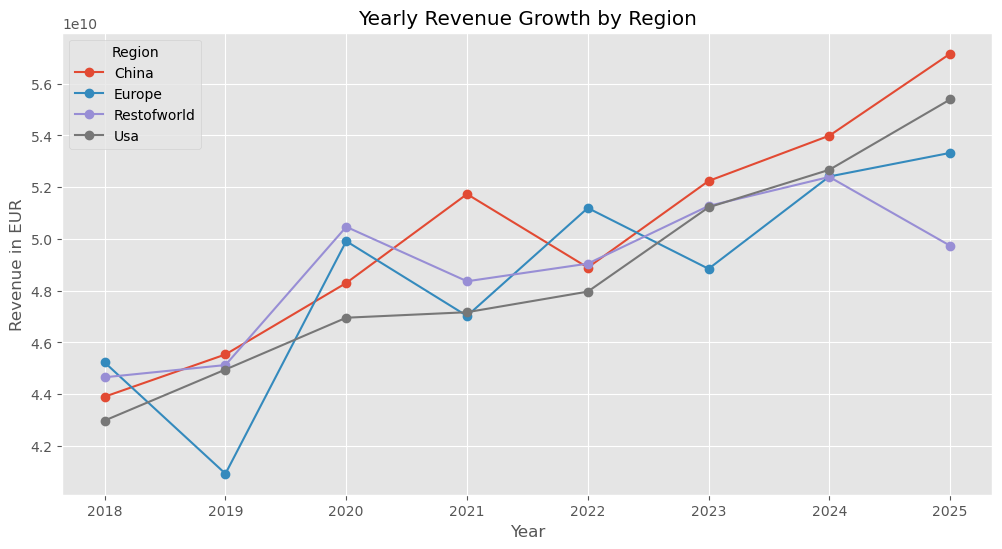

In [59]:
##(كيف تتطور الإيرادات السنوية في كل منطقة جغرافية؟)
##لاستفادة: المقارنة بين سرعة نمو الأسواق المختلفة (مثل السوق الصيني مقابل الأوروبي) واكتشاف أي تراجع في مناطق معينة لاتخاذ إجراءات تصحيحية.
yearly_revenue = df.pivot_table(index='Year', columns='Region', values='Revenue_EUR', aggfunc='sum')
yearly_revenue
yearly_revenue.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Yearly Revenue Growth by Region')
plt.ylabel('Revenue in EUR')
plt.xlabel('Year')
plt.grid(True)
plt.legend(title='Region')
plt.show()

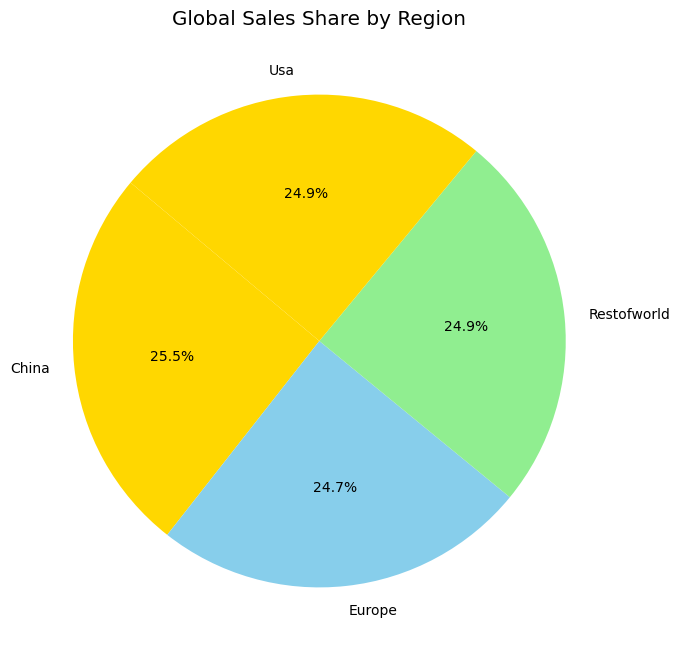

In [60]:
##(ما هي الحصة المئوية لكل منطقة من إجمالي المبيعات؟)
##الاستفادة: معرفة مدى تركز مبيعات الشركة؛ هل الشركة تعتمد بشكل كلي على سوق واحد؟ هذا يساعد في إدارة مخاطر التوسع الجغرافي.
region_share = df.groupby('Region')['Units_Sold'].sum()
region_share
plt.figure(figsize=(8, 8))
region_share.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['gold', 'skyblue', 'lightgreen'])
plt.title('Global Sales Share by Region')
plt.ylabel('') # Hide y-label for better look
plt.show()

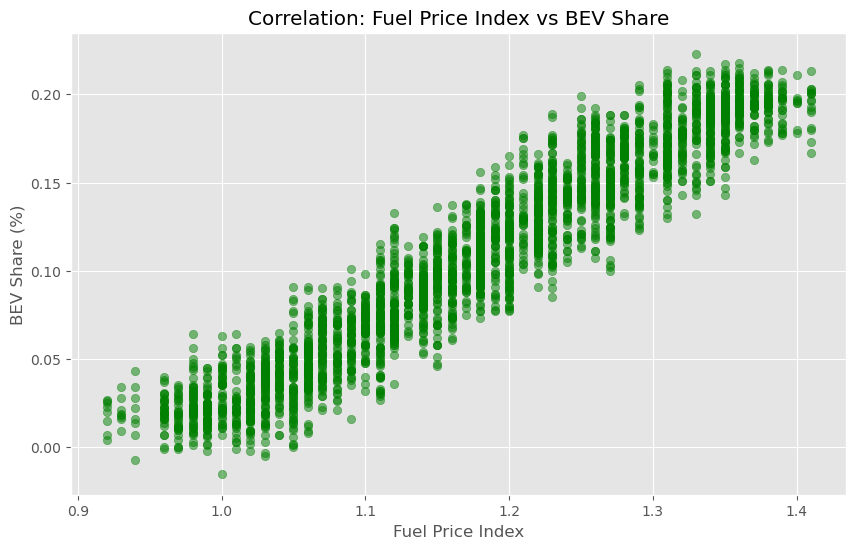

In [62]:
##(هل هناك علاقة بين أسعار الوقود ونسبة مبيعات السيارات الكهربائية؟)
##استفادة: فهم سلوك المستهلك؛ هل يهرب الناس للسيارات الكهربائية عند غلاء البنزين؟ هذا يساعد الشركة على توقع الطلب المستقبلي بناءً على أسعار الطاقة.
plt.figure(figsize=(10, 6))
plt.scatter(df['Fuel_Price_Index'], df['BEV_Share'], alpha=0.5, color='green')
plt.title('Correlation: Fuel Price Index vs BEV Share')
plt.xlabel('Fuel Price Index')
plt.ylabel('BEV Share (%)')
plt.grid(True)
plt.show()

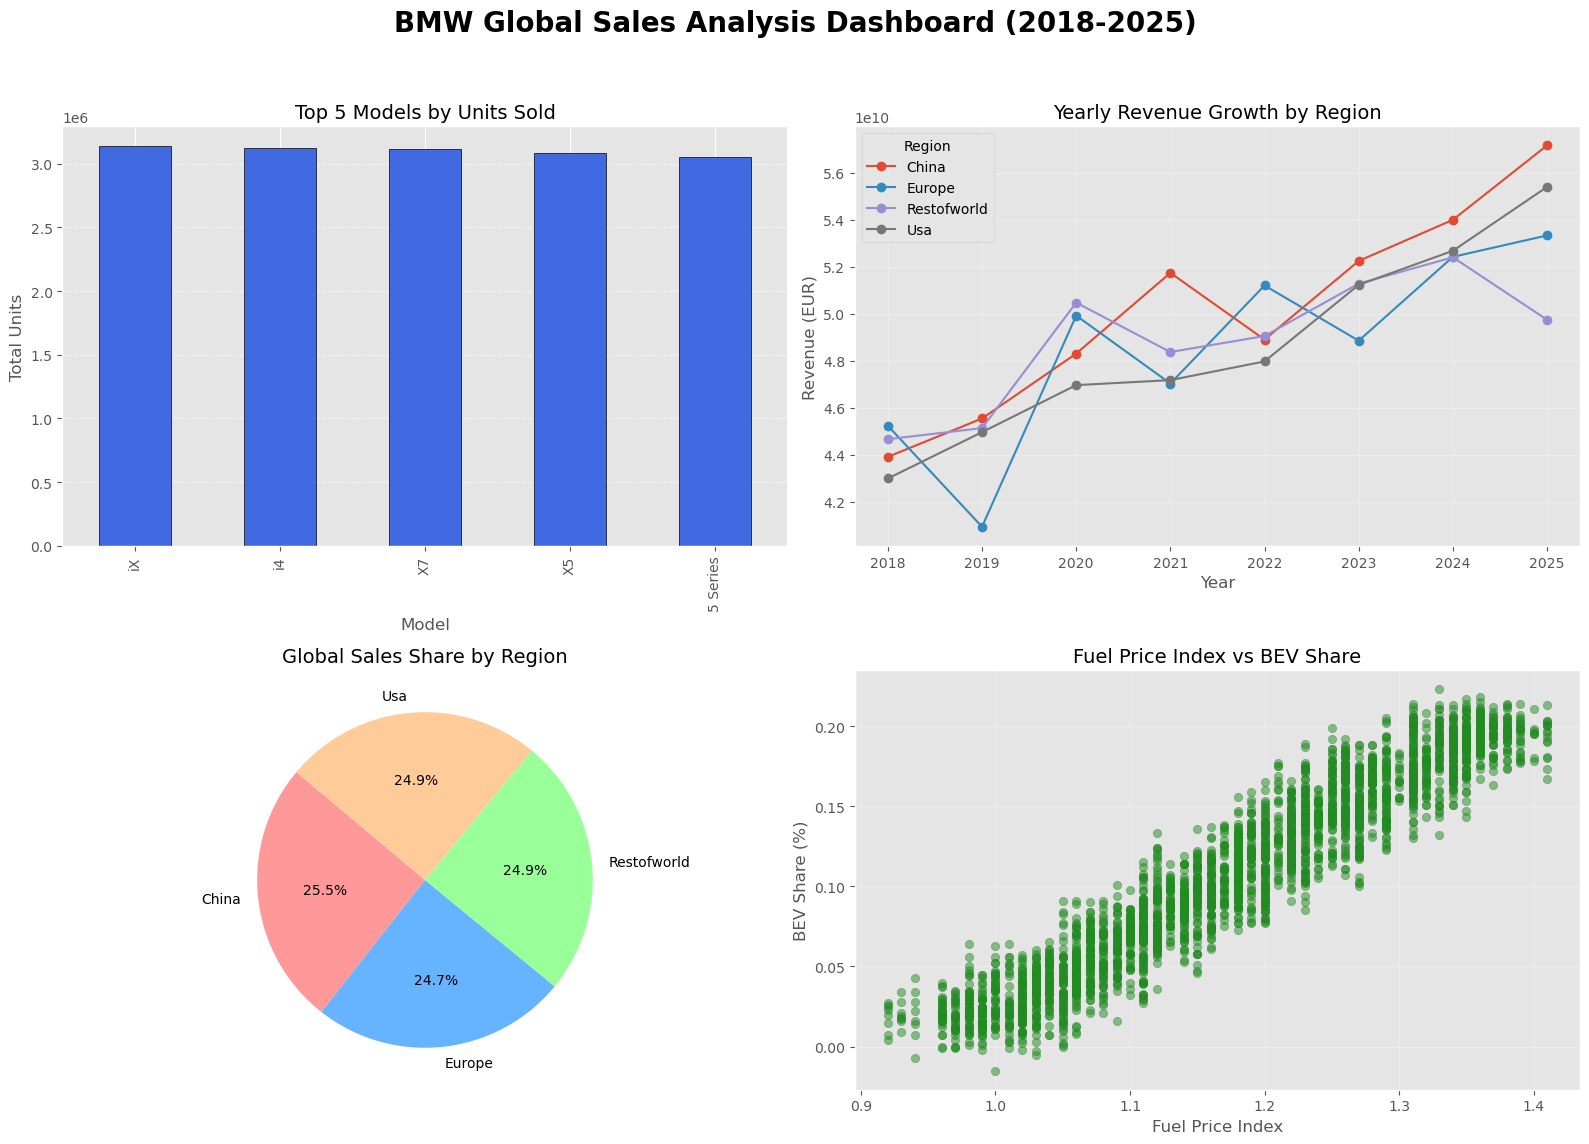

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('BMW Global Sales Analysis Dashboard (2018-2025)', fontsize=20, fontweight='bold')

# --- الرسم الأول: Top 5 Models (Bar Chart) ---
top_models = df.groupby('Model')['Units_Sold'].sum().sort_values(ascending=False).head(5)
top_models.plot(kind='bar', ax=axes[0, 0], color='royalblue', edgecolor='black')
axes[0, 0].set_title('Top 5 Models by Units Sold', fontsize=14)
axes[0, 0].set_ylabel('Total Units')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.6)

# --- الرسم الثاني: Revenue Growth by Region (Line Chart) ---
yearly_rev = df.pivot_table(index='Year', columns='Region', values='Revenue_EUR', aggfunc='sum')
yearly_rev.plot(kind='line', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Yearly Revenue Growth by Region', fontsize=14)
axes[0, 1].set_ylabel('Revenue (EUR)')
axes[0, 1].grid(True, alpha=0.3)

# --- الرسم الثالث: Sales Share by Region (Pie Chart) ---
region_share = df.groupby('Region')['Units_Sold'].sum()
axes[1, 0].pie(region_share, labels=region_share.index, autopct='%1.1f%%', 
               startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
axes[1, 0].set_title('Global Sales Share by Region', fontsize=14)

# --- الرسم الرابع: Fuel Price vs BEV Share (Scatter Plot) ---
axes[1, 1].scatter(df['Fuel_Price_Index'], df['BEV_Share'], alpha=0.5, color='forestgreen')
axes[1, 1].set_title('Fuel Price Index vs BEV Share', fontsize=14)
axes[1, 1].set_xlabel('Fuel Price Index')
axes[1, 1].set_ylabel('BEV Share (%)')
axes[1, 1].grid(True, alpha=0.3)

# تحسين المسافات بين الرسومات
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# عرض اللوحة النهائية
plt.show()

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

In [67]:
df=pd.read_csv(r"C:\Users\K.Asus\Desktop\programing\Data_Analysis\TEST\داتا BMW\archive\bmw_global_sales_2018_2025.csv")

In [68]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [70]:
df.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

In [71]:
df[['Units_Sold', 'Avg_Price_EUR', 'Revenue_EUR']].describe()

,Units_Sold,Avg_Price_EUR,Revenue_EUR
count,3072.000000,3072.000000,3.072000e+03
mean,7980.288086,63854.561523,5.113995e+08
std,3174.917444,14655.891299,2.431185e+08
min,2379.000000,40011.000000,1.045314e+08
25%,5225.500000,54500.250000,3.125504e+08
50%,7985.500000,63493.000000,4.808690e+08
75%,10528.250000,71489.500000,6.709141e+08
max,15914.000000,93994.000000,1.433482e+09


In [76]:
# بنتأكد إن كل الأعمدة الحسابية أرقام فعلاً# 3. حذف أي صفوف فاضية تماماً أو فيها قيم ناقصة في الأعمدة الأساسية
df.dropna(subset=['Units_Sold', 'Revenue_EUR'], inplace=True)
cols_to_fix = ['Units_Sold', 'Avg_Price_EUR', 'Revenue_EUR', 'BEV_Share', 'GDP_Growth']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [77]:
# حذف أي صفوف فاضية تماماً أو فيها قيم ناقصة في الأعمدة الأساسية
df.dropna(subset=['Units_Sold', 'Revenue_EUR'], inplace=True)

In [78]:
#توحيد نصوص الـ Region والـ Model (عشان ميبقاش فيه مسافات زيادة)
df['Region'] = df['Region'].str.strip()
df['Model'] = df['Model'].str.strip()

In [81]:
##اتاكد من انا الداتا نظيفه 
# 1. اختبار القيم الناقصة (Nulls)
print("1. عدد القيم الناقصة في كل عمود:")
print(df.isnull().sum())

# 2. اختبار القيم المكررة (Duplicates)
print("\n2. عدد الصفوف المكررة:", df.duplicated().sum())

# 3. اختبار المنطقية (Logic Check)
# هل فيه سعر أو كمية مبيعات بالسالب؟
negative_check = df[(df['Units_Sold'] <= 0) | (df['Avg_Price_EUR'] <= 0)]
print("\n3. عدد الصفوف اللي فيها قيم سالبة أو صفر (يجب أن يكون 0):", len(negative_check))

# 4. اختبار التفرد (Uniqueness)
# هل نفس الموديل متكرر في نفس المنطقة في نفس الشهر والسنة؟ (مفروض لا)
unique_check = df.duplicated(subset=['Year', 'Month', 'Region', 'Model']).sum()
print("\n4. عدد السجلات المتكررة لنفس الموديل والمنطقة في نفس الوقت:", unique_check)

1. عدد القيم الناقصة في كل عمود:
Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

2. عدد الصفوف المكررة: 0

3. عدد الصفوف اللي فيها قيم سالبة أو صفر (يجب أن يكون 0): 0

4. عدد السجلات المتكررة لنفس الموديل والمنطقة في نفس الوقت: 0


In [87]:
df.to_csv(r"C:\Users\K.Asus\Desktop\programing\Data_Analysis\TEST\داتا BMW\archive\bmw2018_2025.csv", index=False)
print("الداتا وصلت يا كينج")

الداتا وصلت يا كينج


In [82]:
import sqlite3

# 1. إنشاء اتصال بقاعدة بيانات (هتتسمى bmw_database.db)
conn = sqlite3.connect('bmw_database.db')

# 2. رفع الداتا النظيفة اللي عملناها في الخطوة اللي فاتت للـ SQL
df.to_sql('sales_table', conn, if_exists='replace', index=False)

print("مبروك! الداتا دلوقتي جوه جدول SQL اسمه sales_table")

# 3. تعال بقى نختبر عضلاتنا في الـ SQL
# سؤال: إيه هي أكتر 5 موديلات حققت إيرادات (Revenue) إجمالية؟
query = """
SELECT Model, SUM(Revenue_EUR) as Total_Revenue
FROM sales_table
GROUP BY Model
ORDER BY Total_Revenue DESC
LIMIT 5;
"""

top_models = pd.read_sql(query, conn)
print("\n--- نتيجة أول Query في SQL: أعلى 5 موديلات إيراداً ---")
print(top_models)

مبروك! الداتا دلوقتي جوه جدول SQL اسمه sales_table

--- نتيجة أول Query في SQL: أعلى 5 موديلات إيراداً ---
      Model  Total_Revenue
0        X7   286427856714
1        iX   235060013889
2        X5   212814244305
3        i4   202904898753
4  5 Series   188992092821
